In [ ]:
#%% PACKAGES
# Basics
import numpy as np                                                          
from math import pi                                                            
import warnings                                                              
import os    

from datetime import datetime, timedelta
from pandas import DataFrame
import geopandas as gpd

from sklearn.preprocessing import MinMaxScaler

# Visualization
import pandas as pd                                                          
import matplotlib.pyplot as plt                                                
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import numpy as np
import seaborn as sns; sns.set_theme(style='white')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator

In [ ]:
#Set the working directory
os.chdir('/Users/Helo/Documents/Action_situee/index-marchabilite-ge/Notebook')

#Read the files
IndexRaw = pd.read_csv('/Users/Helo/Documents/Action_situee/index-marchabilite-ge/Data/output/step-2/step2_features.csv')

file_path = '/Users/Helo/Documents/Action_situee/index-marchabilite-ge/Data/input'
# If the file attributes_info exists, load it
if os.path.exists(f"{file_path}/attributs_info.csv"):
    attributs_info = pd.read_csv(f"{file_path}/attributs_info.csv")

In [3]:
# Fill NULL
Indexv1 = IndexRaw.fillna(0)

# Create mapping for processed columns while keeping first 5 columns unchanged
attribute_mapping = {}
for _, row in attributs_info.iterrows():
    old_name = f"{row['attribute']}_{row['method']}_{row['buffer_size']}"
    new_name = row['attribute']
    attribute_mapping[old_name] = new_name

# Keep first 5 columns as is, rename the rest using the mapping
first_5_cols = IndexRaw.columns[:5].tolist()
Indexv1 = Indexv1.rename(columns=attribute_mapping)

# Debug info
print("First 5 columns:", first_5_cols)
print("Renamed columns:", [col for col in Indexv1.columns if col not in first_5_cols])

Indexv1

First 5 columns: ['osmid', 'maxspeed', 'geometry', 'segment_id', 'length']
Renamed columns: ['arbre', 'accident', 'toilette', 'vitesse', 'eau', 'rez_actif']


,osmid,maxspeed,geometry,segment_id,length,arbre,accident,toilette,vitesse,eau,rez_actif
0,"[359376368, 404787126, 105225263]",60,LINESTRING (2501993.5755479396 1125460.8049739...,0,50.000000,23.0,0.0,1.0,0.0,1.0,1.0
1,"[359376368, 404787126, 105225263]",60,LINESTRING (2501978.0441964082 1125413.2879790...,1,50.000000,20.0,0.0,1.0,0.0,1.0,1.0
2,"[359376368, 404787126, 105225263]",60,LINESTRING (2501960.8648718493 1125366.3323752...,2,50.000000,19.0,0.0,1.0,0.0,1.0,10.0
3,"[359376368, 404787126, 105225263]",60,LINESTRING (2501942.7863589316 1125319.7165594...,3,50.000000,14.0,0.0,1.0,0.0,3.0,3.0
4,"[359376368, 404787126, 105225263]",60,LINESTRING (2501924.4464080045 1125273.2015532...,4,50.000000,7.0,0.0,1.0,0.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
255221,254698532,0,LINESTRING (2503843.9998960383 1117174.5066915...,255221,46.032927,0.0,0.0,0.0,0.0,0.0,0.0
255222,254698532,0,LINESTRING (2503843.9998960383 1117174.5066915...,255222,45.076761,0.0,0.0,0.0,0.0,0.0,0.0
255223,"[28044788, 1415957982]",0,LINESTRING (2503843.9998960383 1117174.5066915...,255223,50.000000,0.0,0.0,0.0,0.0,0.0,0.0
255224,"[28044788, 1415957982]",0,LINESTRING (2503839.3591829767 1117126.8632471...,255224,50.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
print('Crop outliers if necessary: --> see Walkability Amsterdam notebook')
Indexv2 = Indexv1.copy()
#Adding intervals (for factors where we have an interval of interest and below or above that interval the situation doesn't affect the walkability)
'''
example
Indexv1['amenities'] = Indexv1['amenities'].clip(upper=50) #more than 50 amenities in 350-meters-radius around segment centroid
'''

#Remove segments of less than 1m length
'''print("Keep only segment > 1 meter")
length_min = 1
Indexv2 = Indexv1[Indexv1['length'] > length_min]'''


Crop outliers if necessary: --> see Walkability Amsterdam notebook


'print("Keep only segment > 1 meter")\nlength_min = 1\nIndexv2 = Indexv1[Indexv1[\'length\'] > length_min]'

In [5]:
attributs_info

,attribute,method,how,value_column,buffer_size
0,arbre,buffer,count,NaN,30.0
1,accident,buffer,sum,PIETONS,50.0
2,toilette,buffer,count,NaN,50.0
3,vitesse,join,NaN,TYPE_ZONE,NaN
4,eau,buffer,count,NaN,100.0
5,rez_actif,buffer,count,NaN,30.0


In [6]:
# Create copy and normalize
Indexv3 = Indexv2.copy()
scaler = MinMaxScaler()

# Track changes during normalization
print("Min max normalization...")
for attribute in attributs_info['attribute']:
    if attribute in Indexv3.columns:
        # Normalize
        Indexv3.loc[:, attribute] = scaler.fit_transform(Indexv3[[attribute]])
    else:
        print(f"Attribute '{attribute}' not found in Indexv3 columns.")

Min max normalization...


In [7]:
# Inverse columns (for factors that have a negative effect on walkability)
Indexv3['accident'] = 1 - Indexv3['accident'] #accident


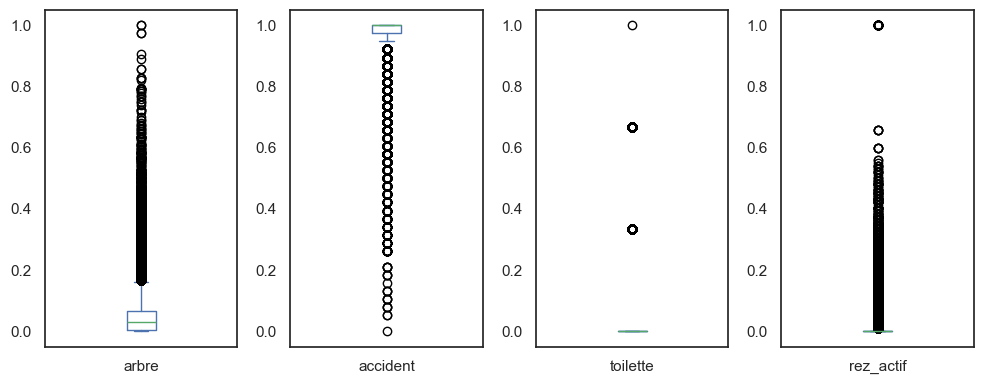

In [8]:
#Check data distribution (use this to check if there are still outliers skewing the factors)

Indexv3[['arbre', 'accident', 'toilette', 'rez_actif']].plot(kind='box', subplots=True, layout=(1, 4), figsize=(10, 4))
plt.tight_layout()
plt.show()


In [9]:
# Calculate the Main Index Scores
Indexv4 = Indexv3

print('Modify weights for main index ->')

#define weights for the main index
Zscore_weights = {
    'arbre': 0.3,
    'accident': 0.1,
    'toilette': 0.1,
    'vitesse': 0.2,
    'eau': 0.1,
    'rez_actif':0.2
}
# add zscore weights to the attributes_info dataframe
attributs_info['weights'] = attributs_info['attribute'].map(Zscore_weights)

# Function to calculate sub-index score
def calculate_index(df, weights_dict):
    return sum(df[col] * weight for col, weight in weights_dict.items())

Indexv4['I-Zscore'] = calculate_index(Indexv4, Zscore_weights)


#Normalising Index
Indexv4['Non-Scaled']=Indexv4['I-Zscore']
Indexv4[['I-Zscore']] = scaler.fit_transform(Indexv4[['I-Zscore']])



Modify weights for main index ->


In [10]:

#%% CLASSES
# Définir les poids pour chaque classe
'''
print('Modify weights for sub-indexes ->>')
feasibility_weights = {
    'N-Furniture': 0.056,
    'N-Green': 0.048,
    'N-ParksPlaza': 0.056,
    'N-ParkinPres': 0.059,
    'N-ProxAmenities': 0.053,
}

accessibility_weights = {
    'N-RoadSafety': 0.094,
    'N-MaxSpeed': 0.073,
}

safety_weights = {
    'N-ProxAmenit': 0.073,
    'N-ShortBlocks': 0.031,
    'N-OV': 0.068,
}

comfort_weights = {
    'N-ProxAmenities': 0.059,
    'N-Crime': 0.071,
    'N-Lighting': 0.074,
}

pleasurability_weights = {
    'N-Obstacles': 0.093,
    'N-SidewalkWi': 0.086,
    'N-Maintenance': 0.065,
}


# Apply to Indexv4 and store results in Indexv5
Indexv5 = Indexv4.copy()
Indexv5['Feasibility'] = calculate_index(Indexv4, feasibility_weights)
Indexv5['Accessibility'] = calculate_index(Indexv4, accessibility_weights)
Indexv5['Safety'] = calculate_index(Indexv4, safety_weights)
Indexv5['Comfort'] = calculate_index(Indexv4, comfort_weights)
Indexv5['Pleasurability'] = calculate_index(Indexv4, pleasurability_weights)


# Min Max Normalisation
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
Indexv5[['Feasability','Accessibility','Safety','Comfort','Pleasurability']] = scaler.fit_transform(Indexv5[['Feasability','Accessibility','Safety','Comfort','Pleasurability']])

'''

"\nprint('Modify weights for sub-indexes ->>')\nfeasibility_weights = {\n    'N-Furniture': 0.056,\n    'N-Green': 0.048,\n    'N-ParksPlaza': 0.056,\n    'N-ParkinPres': 0.059,\n    'N-ProxAmenities': 0.053,\n}\n\naccessibility_weights = {\n    'N-RoadSafety': 0.094,\n    'N-MaxSpeed': 0.073,\n}\n\nsafety_weights = {\n    'N-ProxAmenit': 0.073,\n    'N-ShortBlocks': 0.031,\n    'N-OV': 0.068,\n}\n\ncomfort_weights = {\n    'N-ProxAmenities': 0.059,\n    'N-Crime': 0.071,\n    'N-Lighting': 0.074,\n}\n\npleasurability_weights = {\n    'N-Obstacles': 0.093,\n    'N-SidewalkWi': 0.086,\n    'N-Maintenance': 0.065,\n}\n\n\n# Apply to Indexv4 and store results in Indexv5\nIndexv5 = Indexv4.copy()\nIndexv5['Feasibility'] = calculate_index(Indexv4, feasibility_weights)\nIndexv5['Accessibility'] = calculate_index(Indexv4, accessibility_weights)\nIndexv5['Safety'] = calculate_index(Indexv4, safety_weights)\nIndexv5['Comfort'] = calculate_index(Indexv4, comfort_weights)\nIndexv5['Pleasurability

In [11]:
# Save it
path = "/Users/Helo/Documents/Action_situee/index-marchabilite-ge/Data/output/step-3"
os.chdir(path)
Indexv4.to_csv('Index-Walkability.csv', index = False)

#After saving, perform a join-by-field value in QGIS with the shapefiles of the street segments. Join using the fields called "ID"

In [12]:
Indexv4.head(5)

,osmid,maxspeed,geometry,segment_id,length,arbre,accident,toilette,vitesse,eau,rez_actif,I-Zscore,Non-Scaled
0,"[359376368, 404787126, 105225263]",60,LINESTRING (2501993.5755479396 1125460.8049739...,0,50.0,0.120419,1.0,0.333333,0.0,0.111111,0.009804,0.389334,0.182531
1,"[359376368, 404787126, 105225263]",60,LINESTRING (2501978.0441964082 1125413.2879790...,1,50.0,0.104712,1.0,0.333333,0.0,0.111111,0.009804,0.378480,0.177819
2,"[359376368, 404787126, 105225263]",60,LINESTRING (2501960.8648718493 1125366.3323752...,2,50.0,0.099476,1.0,0.333333,0.0,0.111111,0.098039,0.415510,0.193895
3,"[359376368, 404787126, 105225263]",60,LINESTRING (2501942.7863589316 1125319.7165594...,3,50.0,0.073298,1.0,0.333333,0.0,0.333333,0.029412,0.416992,0.194539
4,"[359376368, 404787126, 105225263]",60,LINESTRING (2501924.4464080045 1125273.2015532...,4,50.0,0.036649,1.0,0.333333,0.0,0.111111,0.019608,0.335963,0.159361


In [ ]:
# Load the original segments with geometries
segments_gdf = gpd.read_file('/Users/Helo/Documents/Action_situee/index-marchabilite-ge/Data/output/step-2/step2_features.gpkg')


In [15]:
#Merge the index with the segments
index_walkability_gdf = gpd.GeoDataFrame(Indexv4, geometry=segments_gdf.geometry)
index_walkability_gdf.crs = segments_gdf.crs  # Ensure CRS matches

In [16]:

#Save merged result to GeoPackage
index_walkability_gdf.to_file('Index-Walkability.gpkg', layer='Index-Walkability', driver='GPKG')